# TensorWave Pricing & Memory-Efficiency Analysis

**Independent competitive analysis — public pricing data, May 2026**  
_Noah Assefa · Ed W. Clark High School · Las Vegas, NV_

---

## Why this matters for TensorWave

TensorWave rents AMD Instinct accelerators (MI300X / MI325X / MI355X) that carry **2.4x–3.6x the on-board memory** of an Nvidia H100 (80 GB). For memory-bound LLM workloads, the buying decision is rarely *price per hour* alone — it is **how much model you can fit per dollar**. This notebook quantifies that advantage so the founders have a single, defensible number to put in front of customers: *memory per dollar*.

Everything below is reproducible from published on-demand list prices.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- Presentation theme: clean white background, consistent palette ----
PALETTE = {
    "tensorwave": "#E8472A",   # accent: red-orange, reserved for TensorWave
    "tw_dark":    "#B5331C",
    "coreweave":  "#1D3557",   # deep navy
    "lambda":     "#457B9D",   # steel blue
    "runpod":     "#8FB8CE",   # light blue
    "ink":        "#1A1A1A",   # near-black text
    "muted":      "#6B7280",   # grey captions
    "grid":       "#E5E7EB",
}

def apply_theme():
    mpl.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": PALETTE["ink"],
        "axes.labelsize": 11,
        "axes.labelcolor": PALETTE["ink"],
        "axes.edgecolor": PALETTE["grid"],
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": PALETTE["grid"],
        "grid.linewidth": 0.8,
        "xtick.color": PALETTE["muted"],
        "ytick.color": PALETTE["muted"],
        "text.color": PALETTE["ink"],
        "legend.frameon": False,
        "figure.dpi": 110,
    })

def style_axes(ax, grid_axis="y"):
    """Strip chartjunk: hide top/right spines, keep light grid on one axis."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(PALETTE["grid"])
    ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.grid(False, axis=("x" if grid_axis == "y" else "y"))

def footnote(fig, text):
    fig.text(0.01, -0.02, text, ha="left", va="top",
             fontsize=8, color=PALETTE["muted"], style="italic")

apply_theme()

## 1. The data

On-demand list prices and on-board VRAM for each provider/GPU. TensorWave SKUs are AMD Instinct; competitors are Nvidia H100 variants (all 80 GB).

**Memory-per-dollar metric.** We define it as:

$$\text{GB per \$/hr} = \frac{\text{VRAM (GB)}}{\text{price (\$/hr)}}$$

This reads as *“how many GB of accelerator memory you rent for each dollar-hour.”* It is the right lens for memory-bound inference/training, but note it measures **capacity efficiency, not compute throughput** — a fair caveat we keep explicit.

In [2]:
# --- On-demand list pricing (public pages, May 2026) ---
data = {
    "Provider":       ["TensorWave", "TensorWave", "TensorWave",
                        "RunPod", "RunPod",
                        "Lambda Labs", "Lambda Labs",
                        "CoreWeave", "CoreWeave"],
    "GPU":            ["MI300X", "MI325X", "MI355X",
                        "H100 PCIe", "H100 SXM5",
                        "H100 PCIe", "H100 SXM5",
                        "H100 PCIe", "H100 HGX"],
    "VRAM_GB":        [192, 256, 288, 80, 80, 80, 80, 80, 80],
    "Price_Per_Hour": [1.71, 2.25, 2.95, 1.99, 2.69, 3.29, 4.09, 4.25, 6.16],
}

df = pd.DataFrame(data)

# Memory per dollar-hour = VRAM / hourly price  (higher = more capacity per $)
df["GB_per_dollar"] = df["VRAM_GB"] / df["Price_Per_Hour"]

df.sort_values("GB_per_dollar", ascending=False).reset_index(drop=True)


,Provider,GPU,VRAM_GB,Price_Per_Hour,GB_per_dollar
0,TensorWave,MI325X,256,2.25,113.777778
1,TensorWave,MI300X,192,1.71,112.280702
2,TensorWave,MI355X,288,2.95,97.627119
3,RunPod,H100 PCIe,80,1.99,40.201005
4,RunPod,H100 SXM5,80,2.69,29.739777
5,Lambda Labs,H100 PCIe,80,3.29,24.316109
6,Lambda Labs,H100 SXM5,80,4.09,19.559902
7,CoreWeave,H100 PCIe,80,4.25,18.823529
8,CoreWeave,H100 HGX,80,6.16,12.987013


## 2. Visualization — price vs. memory efficiency

Two panels on a shared, sorted layout. **TensorWave is the red-orange accent**; every Nvidia-based competitor is a neutral blue so the comparison reads at a glance. Left: raw hourly price (where TensorWave is already competitive). Right: the metric that actually wins deals — memory per dollar.

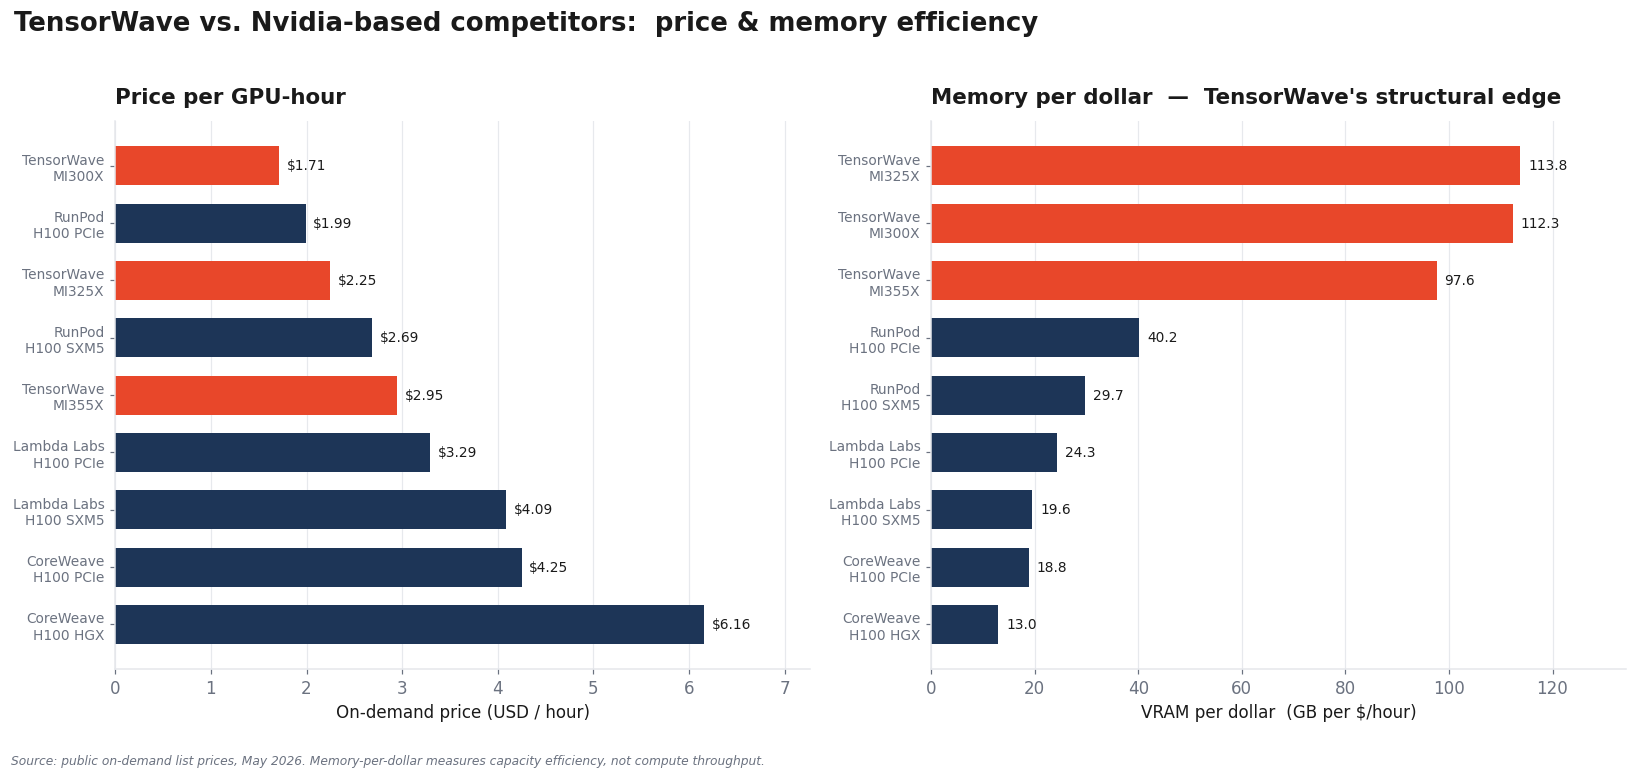

In [3]:
os.makedirs("visualizations", exist_ok=True)

def bar_color(provider):
    return PALETTE["tensorwave"] if provider == "TensorWave" else PALETTE["coreweave"]

labels = [f"{r.Provider} {r.GPU}" for r in df.itertuples()]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# ---- Panel 1: price per hour (sorted ascending, horizontal) ----
d1 = df.sort_values("Price_Per_Hour", ascending=True).reset_index(drop=True)
y1 = np.arange(len(d1))
colors1 = [bar_color(p) for p in d1["Provider"]]
axes[0].barh(y1, d1["Price_Per_Hour"], color=colors1, height=0.68)
axes[0].set_yticks(y1)
axes[0].set_yticklabels([f"{r.Provider}\n{r.GPU}" for r in d1.itertuples()], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("On-demand price (USD / hour)")
axes[0].set_title("Price per GPU-hour", loc="left", pad=12)
for yi, v in zip(y1, d1["Price_Per_Hour"]):
    axes[0].text(v + 0.08, yi, f"${v:,.2f}", va="center", ha="left",
                 fontsize=9, color=PALETTE["ink"])
axes[0].set_xlim(0, d1["Price_Per_Hour"].max() * 1.18)
style_axes(axes[0], grid_axis="x")

# ---- Panel 2: memory per dollar (sorted descending, horizontal) ----
d2 = df.sort_values("GB_per_dollar", ascending=True).reset_index(drop=True)
y2 = np.arange(len(d2))
colors2 = [bar_color(p) for p in d2["Provider"]]
axes[1].barh(y2, d2["GB_per_dollar"], color=colors2, height=0.68)
axes[1].set_yticks(y2)
axes[1].set_yticklabels([f"{r.Provider}\n{r.GPU}" for r in d2.itertuples()], fontsize=9)
axes[1].set_xlabel("VRAM per dollar  (GB per $/hour)")
axes[1].set_title("Memory per dollar  —  TensorWave's structural edge", loc="left", pad=12)
for yi, v in zip(y2, d2["GB_per_dollar"]):
    axes[1].text(v + 1.5, yi, f"{v:,.1f}", va="center", ha="left",
                 fontsize=9, color=PALETTE["ink"])
axes[1].set_xlim(0, d2["GB_per_dollar"].max() * 1.18)
style_axes(axes[1], grid_axis="x")

fig.suptitle("TensorWave vs. Nvidia-based competitors:  price & memory efficiency",
             fontsize=17, fontweight="bold", x=0.012, ha="left", y=1.02)
footnote(fig, "Source: public on-demand list prices, May 2026. "
              "Memory-per-dollar measures capacity efficiency, not compute throughput.")
plt.tight_layout()
plt.savefig("visualizations/pricing_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Key findings

The headline number TensorWave can defend on stage.

In [4]:
# Clean boolean-mask lookups (no chained indexing)
def gbpd(gpu, provider=None):
    m = df["GPU"] == gpu
    if provider is not None:
        m &= df["Provider"] == provider
    return df.loc[m, "GB_per_dollar"].iloc[0]

tw_mi300x = gbpd("MI300X")
cw_hgx    = gbpd("H100 HGX", "CoreWeave")
lam_sxm5  = gbpd("H100 SXM5", "Lambda Labs")

print("=== KEY FINDINGS (memory per dollar, GB per $/hr) ===")
print(f"TensorWave MI300X     : {tw_mi300x:6.1f}")
print(f"CoreWeave  H100 HGX   : {cw_hgx:6.1f}")
print(f"Lambda Labs H100 SXM5 : {lam_sxm5:6.1f}")
print()
print(f"TensorWave delivers {tw_mi300x/cw_hgx:.1f}x more memory per dollar than CoreWeave")
print(f"TensorWave delivers {tw_mi300x/lam_sxm5:.1f}x more memory per dollar than Lambda Labs")


=== KEY FINDINGS (memory per dollar, GB per $/hr) ===
TensorWave MI300X     :  112.3
CoreWeave  H100 HGX   :   13.0
Lambda Labs H100 SXM5 :   19.6

TensorWave delivers 8.6x more memory per dollar than CoreWeave
TensorWave delivers 5.7x more memory per dollar than Lambda Labs


### Reading the result

- **8.6x more memory per dollar than CoreWeave**, **5.7x vs Lambda Labs** — driven by the MI300X's 192 GB versus the H100's 80 GB.
- This is a *capacity* advantage. It converts directly into dollars whenever a model is large enough to need **more than one** Nvidia GPU but still fits on **one** TensorWave card — the mechanism the break-even model (notebook `02`) makes precise.
- **Caveat kept honest:** this does not claim equal per-GPU compute. The retention thesis rests on memory-bound economics, which is where AMD's hardware genuinely leads.